# Delta Sensitivity Analysis

Evaluates robustness of the backfire effect across a 3×3 grid of:
- **δ_ρ** (`delta_rho`): posting-probability adjustment rate ∈ {0.05, 0.1, 0.2}
- **δ_ε** (`delta_epsilon`): bounded-confidence decay rate ∈ {0.95, 0.99, 0.999}

Baseline: HolmeKim (m=3, A=1, pt=0.3), μ=0.8, ε_s=0.5, target=+1.0.  
30 seeds attempted per condition; analysis uses up to **15 valid seeds** (targeting succeeded at step 20000).

**Backfire metric** (consistent with `structural-backfire-analysis.ipynb`):
```
b = log(v_opp_post / v_opp_pre) − log(v_tgt_post / v_tgt_pre)
```
where v = mean posts per step from the respective group over the window.  
Positive → opposing group grew more (relative to baseline) than target group → backfire confirmed.

**Windows**: PRE = steps 19000–20000; POST = steps 39000–40000.

In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from scipy import stats

SA_DIR      = './results/sa_delta'
TARGET_SIGN = 1.0
PRE_RANGE   = (19000, 20000)
POST_RANGE  = (39000, 40000)
BINS        = ['bin_0', 'bin_1', 'bin_2', 'bin_3', 'bin_4']
MAX_VALID   = 15   # max seeds to use per condition after filtering

DELTA_RHOS     = [0.05, 0.1, 0.2]
DELTA_EPSILONS = [0.95, 0.99, 0.999]

print('Imports OK.')

Imports OK.


In [2]:
# ---------------------------------------------------------------------------
# Helpers — identical logic to structural-backfire-analysis.ipynb
# ---------------------------------------------------------------------------

def _gexf_has_target(fpath):
    """Return True if any node in the GEXF has target=True."""
    try:
        tree = ET.parse(fpath)
        root = tree.getroot()
        for elem in root.iter():
            if '}' in elem.tag:
                elem.tag = elem.tag.split('}', 1)[1]
        attr_map = {}
        for attr in root.findall(".//attributes[@class='node']/attribute"):
            attr_map[attr.get('id')] = attr.get('title')
        for node in root.findall(".//node"):
            for av in node.findall(".//attvalue"):
                title = attr_map.get(av.get('for'), av.get('for'))
                if title == 'target' and av.get('value', '').lower() == 'true':
                    return True
    except Exception:
        pass
    return False


def compute_backfire_effect(run_dir, target_sign, pre_range, post_range):
    """
    b = log(v_opp_post / v_opp_pre) - log(v_tgt_post / v_tgt_pre)
    where v = mean posts per step from the respective bin group.
    Positive => backfire. Returns np.nan on early stop, missing data, or v_pre <= 0.
    """
    post_dir = os.path.join(run_dir, 'posts')
    files = glob.glob(os.path.join(post_dir, 'post_result_*.csv'))
    if not files:
        return np.nan

    dfs = []
    for f in files:
        try:
            dfs.append(pd.read_csv(f))
        except Exception:
            pass
    if not dfs:
        return np.nan

    df = pd.concat(dfs, ignore_index=True).sort_values('step')

    if df['step'].max() < post_range[0]:  # early stop
        return np.nan

    if target_sign > 0:
        target_bins   = ['bin_3', 'bin_4']
        opposite_bins = ['bin_0', 'bin_1']
    else:
        target_bins   = ['bin_0', 'bin_1']
        opposite_bins = ['bin_3', 'bin_4']

    def mean_count(df, bins, step_range):
        """Mean total posts per step from the given bins over the window."""
        mask = (df['step'] >= step_range[0]) & (df['step'] <= step_range[1])
        sub = df[mask]
        if sub.empty:
            return np.nan
        return sub[bins].sum(axis=1).mean()

    v_tgt_pre    = mean_count(df, target_bins,   pre_range)
    v_tgt_post   = mean_count(df, target_bins,   post_range)
    v_opp_pre    = mean_count(df, opposite_bins, pre_range)
    v_opp_post   = mean_count(df, opposite_bins, post_range)

    if any(np.isnan(v) for v in [v_tgt_pre, v_tgt_post, v_opp_pre, v_opp_post]):
        return np.nan
    if v_tgt_pre <= 0 or v_opp_pre <= 0 or v_tgt_post <= 0 or v_opp_post <= 0:
        return np.nan

    return np.log(v_opp_post / v_opp_pre) - np.log(v_tgt_post / v_tgt_pre)


print('Helpers defined.')

Helpers defined.


In [3]:
# ---------------------------------------------------------------------------
# Collect all (condition, seed) records; report valid-seed counts
# ---------------------------------------------------------------------------
records = []

for dr in DELTA_RHOS:
    for de in DELTA_EPSILONS:
        label    = f'dr{dr}_de{de}'
        cond_dir = os.path.join(SA_DIR, label)

        seed_dirs = sorted(glob.glob(os.path.join(cond_dir, 'seed_*')))
        if not seed_dirs:
            print(f'[WARN] {label}: no seed directories found')
            continue

        for sd in seed_dirs:
            m    = re.search(r'seed_(\d+)', os.path.basename(sd))
            seed = int(m.group(1)) if m else -1

            gexf_files = glob.glob(os.path.join(sd, 'GEXF', '*', 'step_20000.gexf'))
            if not gexf_files:
                gexf_files = glob.glob(os.path.join(sd, 'GEXF', 'step_20000.gexf'))
            has_target = any(_gexf_has_target(f) for f in gexf_files) if gexf_files else False

            be = compute_backfire_effect(sd, TARGET_SIGN, PRE_RANGE, POST_RANGE)

            records.append({
                'delta_rho':       dr,
                'delta_epsilon':   de,
                'label':           label,
                'seed':            seed,
                'has_target':      has_target,
                'backfire_effect': be,
            })

df_raw = pd.DataFrame(records)

print(f'Total runs collected : {len(df_raw)}')
summary = df_raw.groupby('label').apply(
    lambda g: pd.Series({
        'attempted':  len(g),
        'valid':      g['has_target'].sum(),
        'early_stop': (~g['has_target']).sum(),
    })
).reset_index()
print(summary.to_string(index=False))

Total runs collected : 270
         label  attempted  valid  early_stop
 dr0.05_de0.95         30     15          15
 dr0.05_de0.99         30     19          11
dr0.05_de0.999         30     25           5
  dr0.1_de0.95         30     16          14
  dr0.1_de0.99         30     22           8
 dr0.1_de0.999         30     24           6
  dr0.2_de0.95         30     16          14
  dr0.2_de0.99         30     18          12
 dr0.2_de0.999         30     19          11


/tmp/ipykernel_4045707/2129500109.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df_raw.groupby('label').apply(


In [4]:
# ---------------------------------------------------------------------------
# Filter to valid seeds; cap at MAX_VALID per condition (lowest seed IDs first)
# ---------------------------------------------------------------------------
df_valid = (
    df_raw[df_raw['has_target'] & df_raw['backfire_effect'].notna()]
    .sort_values(['label', 'seed'])
    .groupby('label', group_keys=False)
    .head(MAX_VALID)
    .reset_index(drop=True)
)

print(f'Valid seeds used per condition (cap={MAX_VALID}):')
print(df_valid.groupby('label')['seed'].count().to_string())
print()
print(df_valid[['label', 'seed', 'backfire_effect']])

Valid seeds used per condition (cap=15):
label
dr0.05_de0.95     15
dr0.05_de0.99     15
dr0.05_de0.999    15
dr0.1_de0.95      15
dr0.1_de0.99      15
dr0.1_de0.999     15
dr0.2_de0.95      15
dr0.2_de0.99      15
dr0.2_de0.999     15

             label  seed  backfire_effect
0    dr0.05_de0.95     5        -0.002687
1    dr0.05_de0.95     6         0.068665
2    dr0.05_de0.95     8         0.037435
3    dr0.05_de0.95     9        -0.006212
4    dr0.05_de0.95    10         0.091183
..             ...   ...              ...
130  dr0.2_de0.999    14        -0.137937
131  dr0.2_de0.999    15         0.145198
132  dr0.2_de0.999    16         0.137387
133  dr0.2_de0.999    17         0.137347
134  dr0.2_de0.999    22         0.475339

[135 rows x 3 columns]


In [5]:
# ---------------------------------------------------------------------------
# Condition-level statistics (on capped valid set)
# ---------------------------------------------------------------------------

def cohen_d_vs_0(x):
    return x.mean() / x.std(ddof=1) if len(x) > 1 and x.std(ddof=1) > 0 else np.nan

agg = (
    df_valid
    .groupby(['delta_rho', 'delta_epsilon'])['backfire_effect']
    .agg(
        n       = 'count',
        mean    = 'mean',
        sd      = lambda x: x.std(ddof=1),
        se      = lambda x: x.std(ddof=1) / np.sqrt(len(x)),
        bf_rate = lambda x: (x > 0).mean(),
        cohen_d = cohen_d_vs_0,
    )
    .reset_index()
)

p_vals = []
for _, row in agg.iterrows():
    sub = df_valid[
        (df_valid['delta_rho']     == row['delta_rho']) &
        (df_valid['delta_epsilon'] == row['delta_epsilon'])
    ]['backfire_effect']
    _, p = stats.ttest_1samp(sub, 0) if len(sub) >= 2 else (np.nan, np.nan)
    p_vals.append(p)
agg['p_vs_0'] = p_vals

print('Condition-level summary  (backfire_effect > 0 = backfire):')
print(agg.to_string(index=False, float_format='{:.4f}'.format))

Condition-level summary  (backfire_effect > 0 = backfire):
 delta_rho  delta_epsilon  n   mean     sd     se  bf_rate  cohen_d  p_vs_0
    0.0500         0.9500 15 0.0378 0.0623 0.0161   0.6000   0.6077  0.0337
    0.0500         0.9900 15 0.0570 0.1834 0.0473   0.6667   0.3109  0.2485
    0.0500         0.9990 15 0.0642 0.2437 0.0629   0.6000   0.2634  0.3250
    0.1000         0.9500 15 0.0149 0.0860 0.0222   0.5333   0.1728  0.5141
    0.1000         0.9900 15 0.0745 0.1122 0.0290   0.8000   0.6642  0.0221
    0.1000         0.9990 15 0.1291 0.2405 0.0621   0.6667   0.5367  0.0565
    0.2000         0.9500 15 0.0181 0.1005 0.0260   0.4667   0.1805  0.4960
    0.2000         0.9900 15 0.0614 0.1021 0.0264   0.8000   0.6017  0.0352
    0.2000         0.9990 15 0.0124 0.2070 0.0535   0.6667   0.0597  0.8206


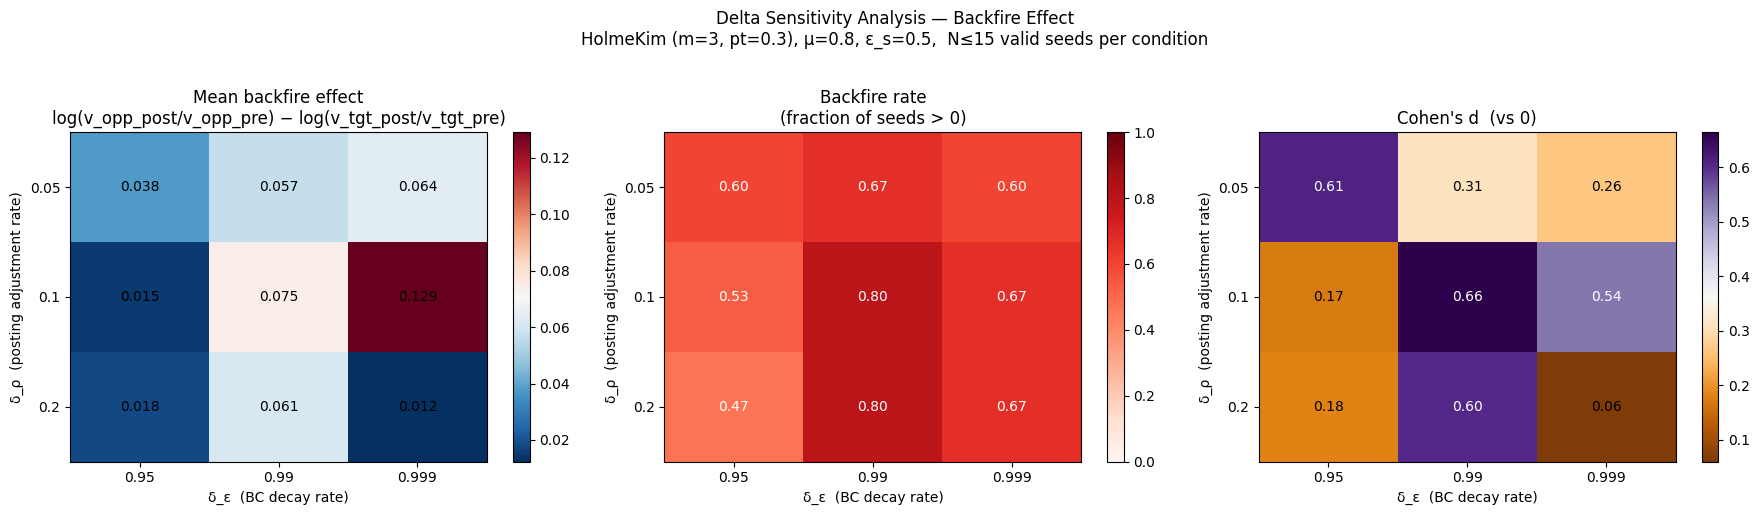

Saved heatmap.


In [6]:
# ---------------------------------------------------------------------------
# Heatmaps: mean BE / backfire rate / Cohen's d
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pivot_mean   = agg.pivot(index='delta_rho', columns='delta_epsilon', values='mean')
pivot_bfrate = agg.pivot(index='delta_rho', columns='delta_epsilon', values='bf_rate')
pivot_d      = agg.pivot(index='delta_rho', columns='delta_epsilon', values='cohen_d')

def draw_heatmap(ax, pivot, title, cmap, fmt='.3f', vmin=None, vmax=None):
    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels([str(c) for c in pivot.columns])
    ax.set_yticklabels([str(r) for r in pivot.index])
    ax.set_xlabel('δ_ε  (BC decay rate)')
    ax.set_ylabel('δ_ρ  (posting adjustment rate)')
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, format(v, fmt), ha='center', va='center',
                        fontsize=10, color='white' if abs(v) > 0.4 else 'black')

draw_heatmap(axes[0], pivot_mean,   'Mean backfire effect\nlog(v_opp_post/v_opp_pre) − log(v_tgt_post/v_tgt_pre)', 'RdBu_r')
draw_heatmap(axes[1], pivot_bfrate, 'Backfire rate\n(fraction of seeds > 0)',    'Reds', fmt='.2f', vmin=0, vmax=1)
draw_heatmap(axes[2], pivot_d,      "Cohen's d  (vs 0)",                         'PuOr',  fmt='.2f')

plt.suptitle(
    'Delta Sensitivity Analysis — Backfire Effect\n'
    'HolmeKim (m=3, pt=0.3), μ=0.8, ε_s=0.5,  N≤15 valid seeds per condition',
    fontsize=12, y=1.02
)
plt.tight_layout()
os.makedirs('results/sa_delta', exist_ok=True)
plt.savefig('results/sa_delta/delta_sensitivity_heatmap.pdf', bbox_inches='tight')
plt.savefig('results/sa_delta/delta_sensitivity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved heatmap.')

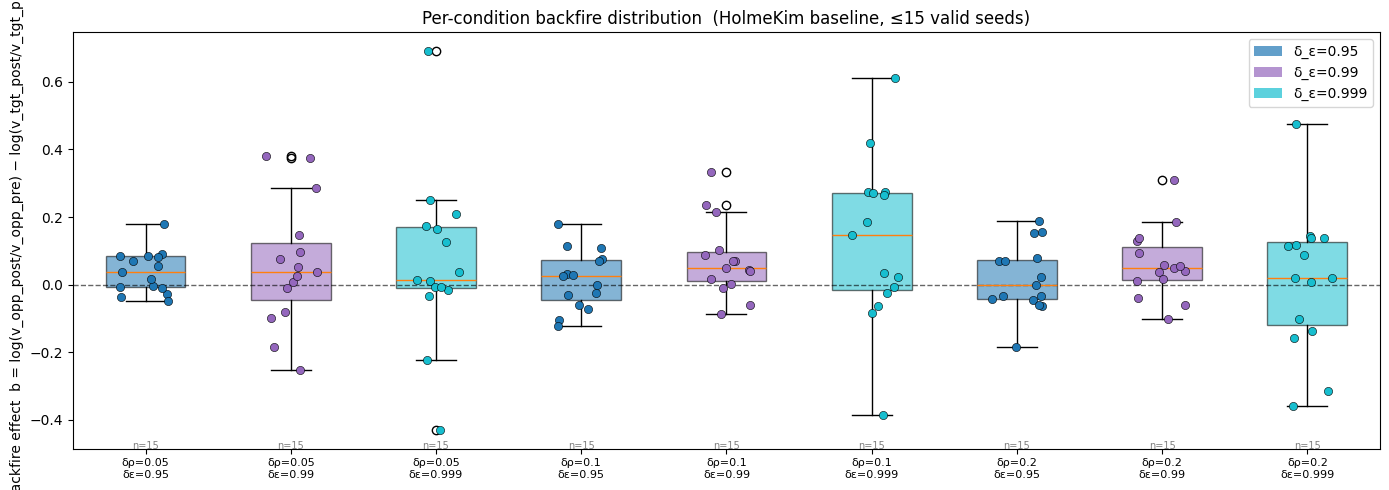

Saved boxplot.


In [7]:
# ---------------------------------------------------------------------------
# Box plots with individual seed points
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))

palette = plt.cm.tab10(np.linspace(0, 0.9, len(DELTA_EPSILONS)))
de_color = {de: palette[i] for i, de in enumerate(DELTA_EPSILONS)}

conditions, data, box_colors = [], [], []
for dr in DELTA_RHOS:
    for de in DELTA_EPSILONS:
        sub = df_valid[
            (df_valid['delta_rho'] == dr) & (df_valid['delta_epsilon'] == de)
        ]['backfire_effect'].dropna()
        conditions.append(f'δρ={dr}\nδε={de}')
        data.append(sub.values)
        box_colors.append(de_color[de])

bp = ax.boxplot(data, positions=range(len(conditions)),
                patch_artist=True, widths=0.55)
for patch, col in zip(bp['boxes'], box_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.55)

rng = np.random.default_rng(0)
for i, (d, col) in enumerate(zip(data, box_colors)):
    jitter = rng.uniform(-0.18, 0.18, len(d))
    ax.scatter(np.full(len(d), i) + jitter, d,
               color=col, s=35, zorder=5, edgecolors='k', linewidths=0.4)
    n_used = len(d)
    ax.text(i, ax.get_ylim()[0] if ax.get_ylim()[0] else -0.15,
            f'n={n_used}', ha='center', fontsize=7, color='grey')

ax.axhline(0, color='k', linewidth=1, linestyle='--', alpha=0.6)
ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(conditions, fontsize=8)
ax.set_ylabel('Backfire effect  b = log(v_opp_post/v_opp_pre) − log(v_tgt_post/v_tgt_pre)')
ax.set_title('Per-condition backfire distribution  (HolmeKim baseline, ≤15 valid seeds)')

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=de_color[de], alpha=0.7, label=f'δ_ε={de}') for de in DELTA_EPSILONS]
ax.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.savefig('results/sa_delta/delta_sensitivity_boxplot.pdf', bbox_inches='tight')
plt.savefig('results/sa_delta/delta_sensitivity_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved boxplot.')

In [8]:
# ---------------------------------------------------------------------------
# Export
# ---------------------------------------------------------------------------
out_csv = 'results/sa_delta/delta_sensitivity_summary.csv'
agg.to_csv(out_csv, index=False, float_format='%.4f')
print(f'Saved: {out_csv}')
print()
print('=== Final summary ===')
print(
    agg[['delta_rho', 'delta_epsilon', 'n', 'mean', 'sd', 'bf_rate', 'cohen_d', 'p_vs_0']]
    .rename(columns={'mean': 'mean_BE', 'sd': 'SD', 'bf_rate': 'BF_rate', 'p_vs_0': 'p(t-test)'})
    .to_string(index=False, float_format='{:.4f}'.format)
)

Saved: results/sa_delta/delta_sensitivity_summary.csv

=== Final summary ===
 delta_rho  delta_epsilon  n  mean_BE     SD  BF_rate  cohen_d  p(t-test)
    0.0500         0.9500 15   0.0378 0.0623   0.6000   0.6077     0.0337
    0.0500         0.9900 15   0.0570 0.1834   0.6667   0.3109     0.2485
    0.0500         0.9990 15   0.0642 0.2437   0.6000   0.2634     0.3250
    0.1000         0.9500 15   0.0149 0.0860   0.5333   0.1728     0.5141
    0.1000         0.9900 15   0.0745 0.1122   0.8000   0.6642     0.0221
    0.1000         0.9990 15   0.1291 0.2405   0.6667   0.5367     0.0565
    0.2000         0.9500 15   0.0181 0.1005   0.4667   0.1805     0.4960
    0.2000         0.9900 15   0.0614 0.1021   0.8000   0.6017     0.0352
    0.2000         0.9990 15   0.0124 0.2070   0.6667   0.0597     0.8206
